In [1]:
!pip install plotly matplotlib seaborn Jovian --upgrade --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.3 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np

In [9]:
import jovian
jovian.commit()

[jovian] Detected Colab notebook...
[jovian] jovian.commit() is no longer required on Google Colab. If you ran this notebook from Jovian, 
then just save this file in Colab using Ctrl+S/Cmd+S and it will be updated on Jovian. 
Also, you can also delete this cell, it's no longer necessary.


In [10]:
import plotly
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [56]:
sns.set_style("darkgrid")
matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["figure.figsize"] = (15, 6)
matplotlib.rcParams["figure.facecolor"] = "#000000"

In [15]:
med_df = pd.read_csv("medical.csv")
med_df

,Age,sex,bmi,children,smoker,region,charges
0,56,male,43.1,2,no,southeast,14484.71
1,46,male,21.7,2,no,northeast,13992.19
2,32,male,27.8,3,no,northwest,12880.25
3,60,male,31.4,0,no,northwest,11870.78
4,25,female,28.4,0,no,southwest,7329.59
...,...,...,...,...,...,...,...
1995,42,female,20.3,2,no,northeast,12220.68
1996,37,female,31.3,1,no,southwest,8573.99
1997,19,female,29.0,2,yes,northwest,22926.46
1998,56,female,46.1,0,no,northwest,12447.97


In [13]:
med_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       2000 non-null   int64  
 1   sex       2000 non-null   object 
 2   bmi       2000 non-null   float64
 3   children  2000 non-null   int64  
 4   smoker    2000 non-null   object 
 5   region    2000 non-null   object 
 6   charges   2000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 109.5+ KB


In [14]:
med_df.describe()

,Age,bmi,children,charges
count,2000.00000,2000.000000,2000.0000,2000.000000
mean,41.31650,30.080500,1.4730,13675.277715
std,13.46566,5.969144,1.1081,6414.381276
min,18.00000,15.000000,0.0000,2232.200000
25%,30.00000,25.800000,1.0000,9519.637500
50%,42.00000,30.150000,1.0000,11589.280000
75%,53.00000,34.300000,2.0000,14411.310000
max,64.00000,50.000000,3.0000,33655.190000


In [28]:
non_smokers_df = med_df[med_df["smoker"] == "no"]

In [29]:
non_smokers_df

,Age,sex,bmi,children,smoker,region,charges
0,56,male,43.1,2,no,southeast,14484.71
1,46,male,21.7,2,no,northeast,13992.19
2,32,male,27.8,3,no,northwest,12880.25
3,60,male,31.4,0,no,northwest,11870.78
4,25,female,28.4,0,no,southwest,7329.59
...,...,...,...,...,...,...,...
1994,56,female,34.8,2,no,northeast,16354.02
1995,42,female,20.3,2,no,northeast,12220.68
1996,37,female,31.3,1,no,southwest,8573.99
1998,56,female,46.1,0,no,northwest,12447.97


In [30]:
fig = px.scatter(non_smokers_df, x = "Age", y = "charges", color = "smoker", title = "Age Vs Charges")
fig.show()

In [27]:
from sklearn.linear_model import LinearRegression

In [49]:
#...define the "helper"
def try_parameters(w_ns, b_ns):
  ages_ns = non_smokers_df.Age
  targets_ns = non_smokers_df.charges
  predictions = w_ns * ages_ns + b_ns
  plt.plot(ages_ns, predictions, "r", alpha = 0.9)
  plt.scatter(ages_ns, targets_ns, s = 8, alpha = 0.6)
  plt.xlabel = ("Age")
  plt.ylabel = ("Charges")
  plt.legend(["Estimated", "Actual"])

In [32]:
#...initialize the model
model = LinearRegression()

In [35]:
#...format inputs and targets
inputs_ns = non_smokers_df[["Age"]]
targets_ns = non_smokers_df.charges
print("inputs_ns.shape:", inputs_ns.shape)
print("targets_ns.shape:", targets_ns.shape)

inputs_ns.shape: (1614, 1)
targets_ns.shape: (1614,)


In [36]:
#...the "fit" training
model.fit(inputs_ns, targets_ns)

LinearRegression()

In [41]:
#...extract the result
w_ns = model.coef_
b_ns = model.intercept_
print("w_ns:", w_ns)
print("b_ns:", b_ns)

w_ns: [50.67665986]
b_ns: 8701.10478934506


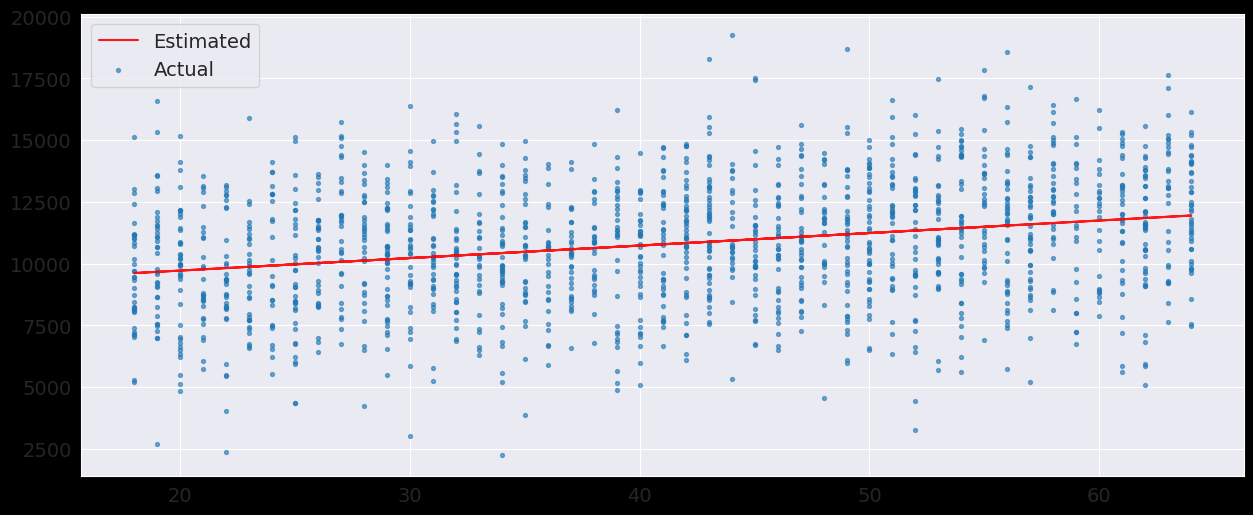

In [57]:
#...using the try_parameters(the visualization)
try_parameters(w_ns, b_ns)

In [52]:
#...predictions and evaluations
predictions = model.predict(inputs_ns)
predictions

array([11538.99774152, 11032.23114292, 10322.75790488, ...,
       10576.14120418, 11538.99774152,  9866.66796613])

In [54]:
targets_ns

,charges
0,14484.71
1,13992.19
2,12880.25
3,11870.78
4,7329.59
...,...
1994,16354.02
1995,12220.68
1996,8573.99
1998,12447.97


In [55]:
rmse = np.sqrt(np.mean(np.square(targets_ns - predictions)))
print("The error is", rmse)

The error is 2424.2418561489453


In [59]:
smokers_df = med_df[med_df["smoker"] == "yes"]
smokers_df

,Age,sex,bmi,children,smoker,region,charges
5,38,female,29.6,2,yes,northeast,25235.34
7,36,male,15.6,2,yes,southwest,21794.13
9,28,male,30.3,0,yes,northwest,24017.19
17,19,male,31.3,1,yes,southwest,23539.73
21,55,male,36.9,1,yes,northeast,28507.20
...,...,...,...,...,...,...,...
1959,51,male,35.9,2,yes,northwest,26511.65
1970,62,male,32.7,2,yes,northeast,24539.56
1982,59,male,26.8,2,yes,northeast,27073.22
1986,19,female,39.9,1,yes,southwest,25475.55


In [61]:
fig = px.scatter(smokers_df, x = "Age", y = "charges", title = "Age Vs Charges")
fig.show()

In [75]:
def try_parameters (w_s, b_s):
 ages_s = smokers_df.Age
 targets_s = smokers_df.charges
 predictions = w_s * ages_s + b_s
 plt.plot(ages_s, predictions, "r", alpha = 0.8)
 plt .scatter(ages_s, targets_s, s = 8, alpha = 0.8)
 plt.legend(["Estimated", "Actual"])

In [63]:
model_s = LinearRegression()

In [64]:
inputs_s = smokers_df[["Age"]]
targets_s = smokers_df.charges
print("inputs_s.shape:", inputs_s.shape)
print("targets_s.shape:", targets_s.shape)

inputs_s.shape: (386, 1)
targets_s.shape: (386,)


In [65]:
model_s.fit(inputs_s, targets_s)

LinearRegression()

In [67]:
w_s = model_s.coef_
b_s = model_s.intercept_
print("w_s:", w_s)
print("b_s:", b_s)

w_s: [51.48405344]
b_s: 23591.883319789573


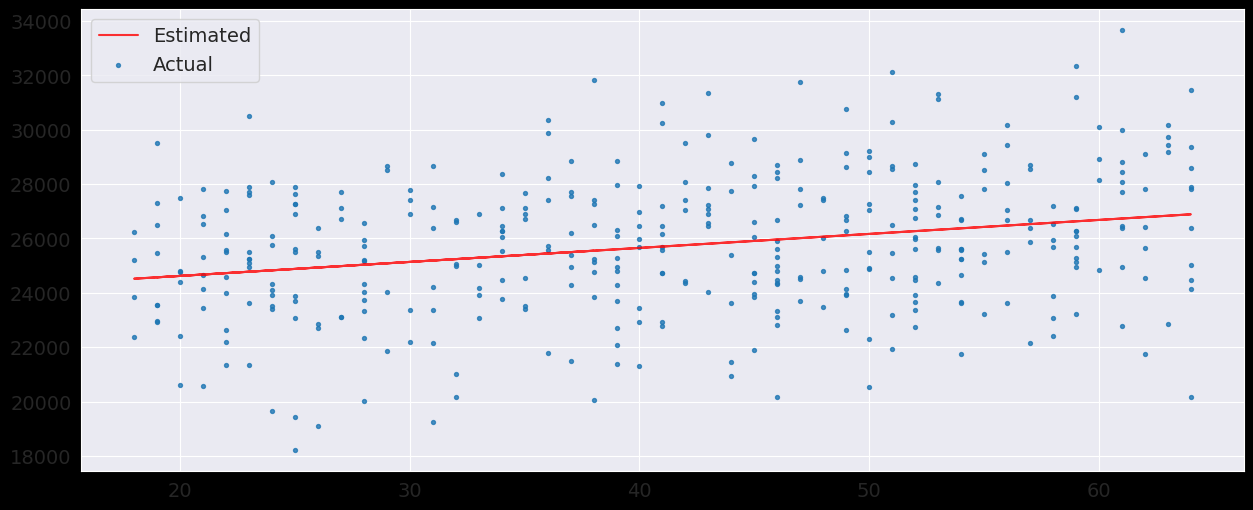

In [76]:
try_parameters(w_s, b_s)

In [94]:
predictions = model_s.predict(inputs_s)
predictions

array([25548.27735057, 25445.30924369, 25033.43681615, 24570.08033518,
       26423.50625908, 25908.66572466, 25290.85708336, 24621.56438862,
       26372.02220563, 25548.27735057, 26474.99031252, 25393.82519024,
       26886.86274005, 26732.41057972, 26629.44247284, 24673.04844206,
       25187.88897648, 26783.89463317, 25754.21356433, 26783.89463317,
       26732.41057972, 25342.3411368 , 26269.05409875, 26269.05409875,
       26577.9584194 , 26166.08599187, 26372.02220563, 25599.76140401,
       25857.18167122, 25805.69761778, 26114.60193843, 26011.63383154,
       26680.92652628, 24827.50060239, 26629.44247284, 26474.99031252,
       25857.18167122, 24776.01654895, 24878.98465583, 26166.08599187,
       26629.44247284, 26114.60193843, 25084.92086959, 24570.08033518,
       26114.60193843, 26732.41057972, 25033.43681615, 26423.50625908,
       25702.72951089, 24776.01654895, 25033.43681615, 25445.30924369,
       25445.30924369, 26526.47436596, 25033.43681615, 26269.05409875,
      

In [81]:
targets_s

,charges
5,25235.34
7,21794.13
9,24017.19
17,23539.73
21,28507.20
...,...
1959,26511.65
1970,24539.56
1982,27073.22
1986,25475.55


In [83]:
rmse = np.sqrt(np.mean(np.square(targets_s - predictions)))
print("The error is", rmse)

The error is 2452.939741936184


In [90]:
smoking_tax_per_year = w_s - w_ns
smoking_tax_per_year


array([0.80739358])

In [92]:
base_difference = b_s - b_ns
base_difference

np.float64(14890.778530444513)